# 準備

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip3 install japanize-matplotlib
import japanize_matplotlib

## CSV読み込み

In [3]:
df_click_logs = pd.read_csv('https://raw.githubusercontent.com/tetsu19n1101087/debugging-simulation/refs/heads/main/python/data/click_logs.csv')
df_selected_rows = pd.read_csv('https://raw.githubusercontent.com/tetsu19n1101087/debugging-simulation/refs/heads/main/python/data/selected_rows.csv')

In [4]:
df_click_logs['occurred_at_jst'] = pd.to_datetime(df_click_logs['occurred_at_jst'])
df_selected_rows['updated_at'] = pd.to_datetime(df_selected_rows['updated_at'])

df_session_task = df_selected_rows[['session_id', 'task', 'correct', 'updated_at']].copy()

df_session_task_unique = df_session_task.drop_duplicates()
df_session_task_unique = df_session_task_unique[df_session_task_unique['correct'].notna()]
display(df_session_task_unique)

,session_id,task,correct,updated_at
14,1ddcd4db-5829-4809-8ac6-a8e16b0b6693,duplicate,True,2025-12-22 10:43:05
19,4813a711-2dc9-41db-9945-8b8d96addf05,duplicate,True,2025-12-18 15:02:57
23,9eb03933-a8cc-4f0f-a071-346af4ce2d01,duplicate,False,2025-12-18 11:19:53
26,e87a9bda-7533-4de0-be74-82f20f3de114,duplicate,False,2025-12-16 11:04:34
32,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,duplicate,True,2025-12-15 11:03:05
35,6ff3d032-dcaf-49ea-971c-1e2942572b61,duplicate,True,2025-12-09 18:17:40
47,bde3507b-3728-44b7-b8f7-6166f7ff1c45,duplicate,True,2025-12-04 14:00:25
53,978a7f0f-7dbf-44c1-b69e-9cda7be9011e,exceed,True,2025-12-18 13:07:23
54,af542900-d8bb-4dbb-abb9-bcac66c09818,exceed,True,2025-12-09 16:25:48
55,df5c4117-7c69-426d-b3b9-b76f2738e039,exceed,False,2025-12-09 18:33:20


In [5]:
# データフレーム結合
df_merged = pd.merge(df_click_logs, df_session_task_unique, on='session_id', how='inner')

# session_idsリストに含まれるsession_idのみでフィルタリング
# df_experiment = df_merged[df_merged['session_id'].isin(session_ids)]
df_experiment = df_merged.copy()

df_experiment = df_experiment.sort_values(by=['occurred_at_jst']).reset_index(drop=True)
df_experiment['stay_time'] = df_experiment.groupby('session_id')['occurred_at_jst'].diff(-1).dt.total_seconds().abs().fillna(0)

In [6]:
last_time = df_experiment.groupby("session_id")["occurred_at_jst"].last()

stay_time = (
    df_session_task_unique.set_index("session_id")["updated_at"]
    .sub(last_time)
    .dt.total_seconds()
)

last_idx = df_experiment.groupby("session_id").tail(1).index
df_experiment.loc[last_idx, "stay_time"] = (
    df_experiment.loc[last_idx, "session_id"].map(stay_time)
)


display(df_experiment)

,session_id,event_type,location,occurred_at_jst,task,correct,updated_at,stay_time
0,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,book.py,2025-12-04 13:47:49,duplicate,True,2025-12-04 14:00:25,7.0
1,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,member.py,2025-12-04 13:47:56,duplicate,True,2025-12-04 14:00:25,1.0
2,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:47:57,duplicate,True,2025-12-04 14:00:25,3.0
3,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,main.py,2025-12-04 13:48:00,duplicate,True,2025-12-04 14:00:25,44.0
4,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,book.py,2025-12-04 13:48:44,duplicate,True,2025-12-04 14:00:25,4.0
...,...,...,...,...,...,...,...,...
1391,8cec8455-6613-4479-87c5-7b2cb3ab6fe6,file,library.py,2025-12-23 11:41:45,exceed,True,2025-12-23 11:43:20,4.0
1392,8cec8455-6613-4479-87c5-7b2cb3ab6fe6,method,Library.borrow_book,2025-12-23 11:41:49,exceed,True,2025-12-23 11:43:20,20.0
1393,8cec8455-6613-4479-87c5-7b2cb3ab6fe6,method,Library.remove_book,2025-12-23 11:42:09,exceed,True,2025-12-23 11:43:20,50.0
1394,8cec8455-6613-4479-87c5-7b2cb3ab6fe6,method,Library.add_member,2025-12-23 11:42:59,exceed,True,2025-12-23 11:43:20,2.0


## main.py への遷移確率

In [54]:
# main.pyへの遷移を分析
# session_idごとに前のlocationを取得
df_experiment['prev_location'] = df_experiment.groupby('session_id')['location'].shift(1)

# main.pyに遷移した行のみ抽出
df_to_main = df_experiment[df_experiment['location'] == 'main.py'].copy()

# 前のlocationの頻度を集計
transition_counts = df_to_main['prev_location'].value_counts()

# 遷移確率を計算
transition_probs = transition_counts / transition_counts.sum()

print("main.pyへの遷移確率:")
display(transition_probs.to_frame(name='probability'))

main.pyへの遷移確率:


,probability
prev_location,
library.py,0.176101
book.py,0.119497
member.py,0.100629
Library.add_book,0.094340
Library.__init__,0.094340
Book.__init__,0.075472
Library.borrow_book,0.069182
Library.return_book,0.044025
Book.__str__,0.031447


# 全データを分析

## データ前処理

In [7]:
filtered_df_experiment_exceed = df_experiment[(df_experiment['event_type'].isin(['method', 'file'])) & (df_experiment['task'] == 'exceed')]
df_exceed = filtered_df_experiment_exceed.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

filtered_df_experiment_duplicate = df_experiment[(df_experiment['event_type'].isin(['method', 'file'])) & (df_experiment['task'] == 'duplicate')]
df_duplicate = filtered_df_experiment_duplicate.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T


# クラスを除いてフィルタリング
locations_to_exclude = ['book.py', 'library.py', 'main.py', 'member.py']

# Filter df_exceed
filtered_df_exceed = df_exceed[~df_exceed.index.isin(locations_to_exclude)]

# Filter df_duplicate
filtered_df_duplicate = df_duplicate[~df_duplicate.index.isin(locations_to_exclude)]

In [8]:
df_duplicate

session_id,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,1ddcd4db-5829-4809-8ac6-a8e16b0b6693,4813a711-2dc9-41db-9945-8b8d96addf05,6ff3d032-dcaf-49ea-971c-1e2942572b61,9eb03933-a8cc-4f0f-a071-346af4ce2d01,bde3507b-3728-44b7-b8f7-6166f7ff1c45,e87a9bda-7533-4de0-be74-82f20f3de114
location,,,,,,,
Book.__del__,51.0,44.0,18.0,23.0,64.0,33.0,57.0
Book.__init__,143.0,81.0,246.0,170.0,184.0,157.0,119.0
Book.__str__,37.0,10.0,0.0,26.0,16.0,21.0,57.0
Library.__init__,22.0,25.0,23.0,34.0,21.0,15.0,58.0
Library.add_book,82.0,19.0,139.0,67.0,132.0,61.0,85.0
Library.add_member,11.0,2.0,0.0,111.0,6.0,0.0,64.0
Library.borrow_book,174.0,8.0,224.0,14.0,7.0,0.0,217.0
Library.remove_book,157.0,19.0,183.0,48.0,3.0,7.0,127.0
Library.remove_member,22.0,2.0,0.0,28.0,0.0,7.0,72.0


In [9]:

def calculate_mean_probability(df):
    total_counts = df.sum(axis=0)

    # 場所ごとの割合
    probs = df.div(total_counts, axis=1)

    # 割合の重みづけ平均
    weights = total_counts / total_counts.sum()
    weighted_avg = (probs * weights).sum(axis=1)

    mean_dist = weighted_avg.to_frame(name='mean_probability')

    return mean_dist, probs

In [10]:
# 全ノードの割合、平均
mean_dist_exceed, probs_exceed = calculate_mean_probability(df_exceed)
mean_dist_duplicate, probs_duplicate = calculate_mean_probability(df_duplicate)

# クラスを除いたノードの割合、平均
mean_dist_exceed_filtered, probs_exceed_filtered = calculate_mean_probability(filtered_df_exceed)
mean_dist_duplicate_filtered, probs_duplicate_filtered = calculate_mean_probability(filtered_df_duplicate)

## 可視化

vmax 要修正

In [31]:
from matplotlib.colors import PowerNorm

def plot_heatmap(df, title, vmin=0, vmax=1):
  plt.figure(figsize=(12, 8))
  sns.heatmap(df, annot=True, cmap='Oranges', fmt=".2f", linewidths=.5, 
              vmin=vmin, vmax=vmax, norm=PowerNorm(gamma=0.5, vmin=0, vmax=1))
  plt.title(title)
  plt.xlabel('参加者 ID')
  plt.ylabel('ソースコード要素')
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

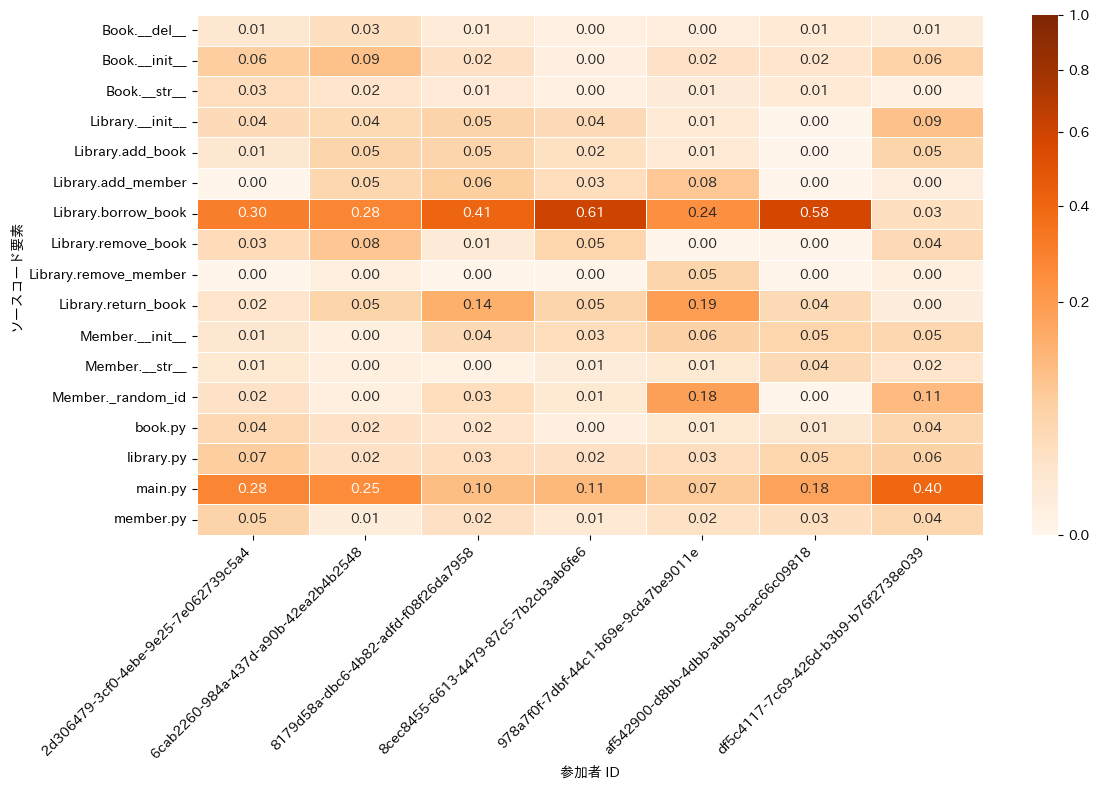

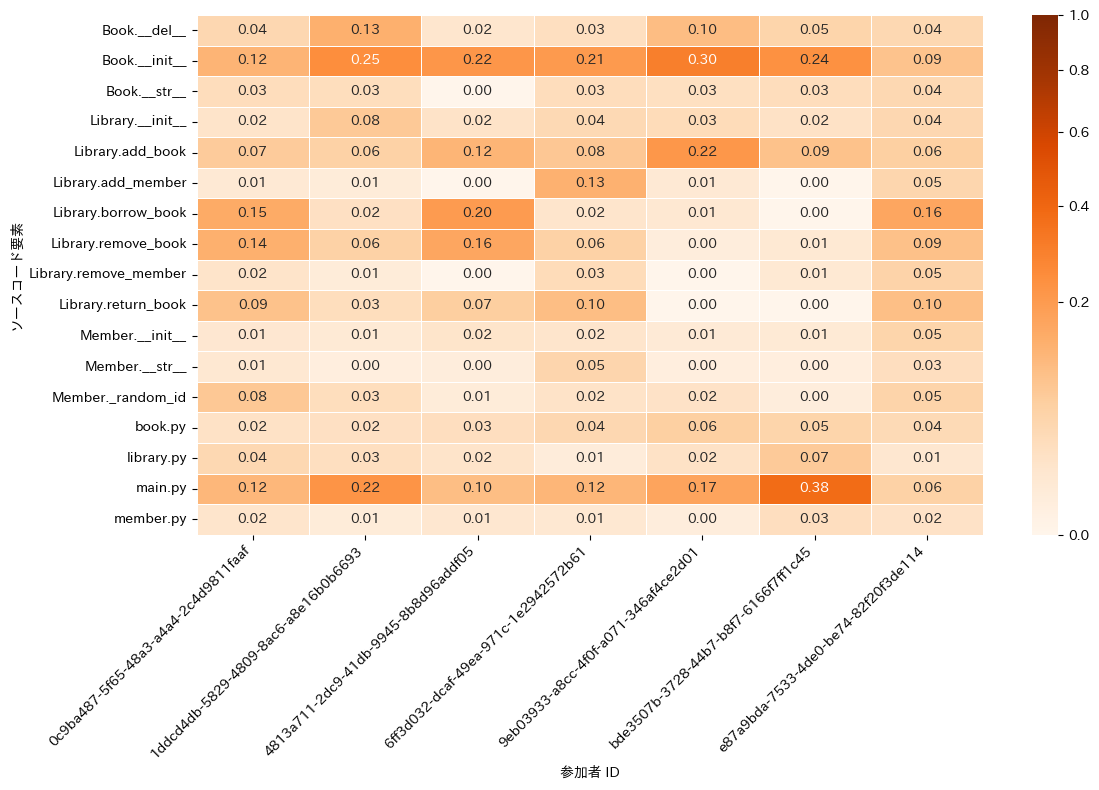

In [32]:
all_data = pd.concat([probs_exceed.stack(), probs_duplicate.stack()])
# vmin = all_data.min()
# vmax = all_data.max()

vmin = 0
vmax = 1

# Plot for 'exceed' task
plot_heatmap(probs_exceed, '', vmin, vmax)

# Plot for 'duplicate' task
plot_heatmap(probs_duplicate, '', vmin, vmax)

### クラスを除いたヒートマップ

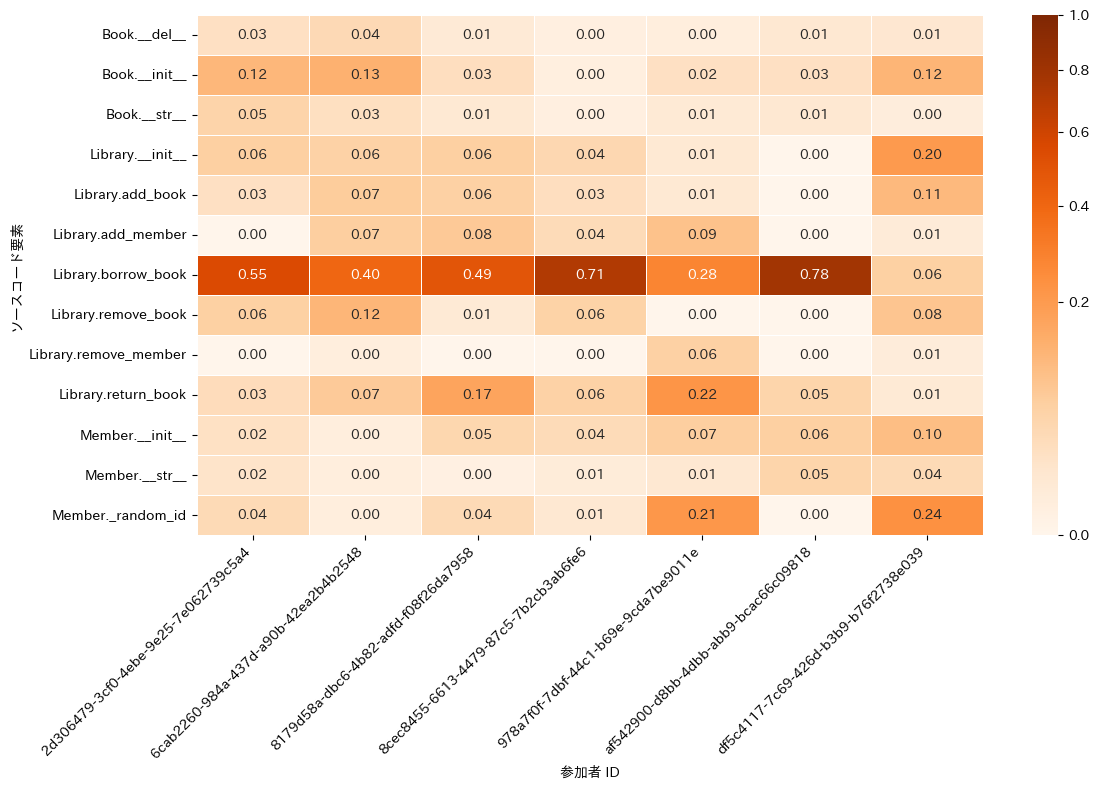

In [33]:
# Plot for 'exceed' task (filtered locations)
plot_heatmap(probs_exceed_filtered, '', vmin, vmax)

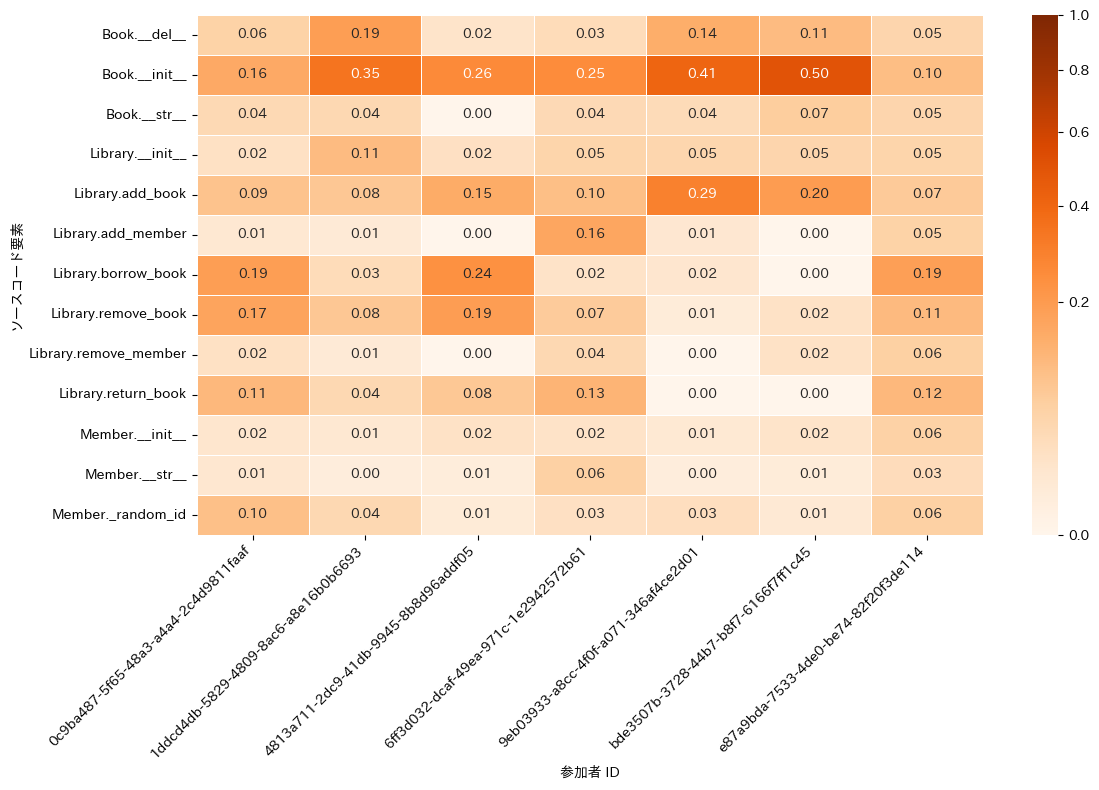

In [34]:
# Plot for 'duplicate' task (filtered locations)
plot_heatmap(probs_duplicate_filtered, '', vmin, vmax)

## モデルとの比較

In [37]:
stationary_distribution_duplicate = pd.read_csv("https://raw.githubusercontent.com/tetsu19n1101087/debugging-simulation/refs/heads/main/python/data/stationary_distribution_duplicate.csv", index_col=0).rename_axis('location').rename(columns={'prob': 'stationary_distribution_duplicate'})
stationary_distribution_exceed = pd.read_csv("https://raw.githubusercontent.com/tetsu19n1101087/debugging-simulation/refs/heads/main/python/data/stationary_distribution_exceed.csv", index_col=0).rename_axis('location').rename(columns={'prob': 'stationary_distribution_exceed'})

stationary_distribution_topology = pd.read_csv("https://raw.githubusercontent.com/tetsu19n1101087/debugging-simulation/refs/heads/main/python/data/stationary_distribution_topology.csv", index_col=0).rename_axis('location').rename(columns={'prob': 'stationary_distribution_topology'})

In [38]:
combined_mean_distributions = pd.concat([mean_dist_duplicate, mean_dist_exceed], axis=1)
combined_mean_distributions.columns = ['mean_probability_duplicate', 'mean_probability_exceed']

final_combined_df = pd.merge(combined_mean_distributions, stationary_distribution_duplicate, left_index=True, right_index=True, how='outer').merge(
    stationary_distribution_exceed, left_index=True, right_index=True, how='outer').merge(
        stationary_distribution_topology, left_index=True, right_index=True, how='outer'
    )

display(final_combined_df)

,mean_probability_duplicate,mean_probability_exceed,stationary_distribution_duplicate,stationary_distribution_exceed,stationary_distribution_topology
location,,,,,
Book.__del__,0.047958,0.007476,0.014,0.085,0.090
Book.__init__,0.181908,0.037104,0.294,0.085,0.090
Book.__str__,0.027617,0.009137,0.014,0.085,0.090
Library.__init__,0.032744,0.050671,0.015,0.024,0.024
Library.add_book,0.096742,0.033366,0.019,0.025,0.024
Library.add_member,0.032082,0.029212,0.017,0.026,0.024
Library.borrow_book,0.106499,0.320781,0.017,0.029,0.024
Library.remove_book,0.089962,0.031427,0.017,0.021,0.024
Library.remove_member,0.021664,0.005399,0.015,0.026,0.024


In [39]:
from scipy.spatial.distance import jensenshannon
import numpy as np

# Extract the relevant columns
r_duplicate = final_combined_df['mean_probability_duplicate'].fillna(0)
r_exceed = final_combined_df['mean_probability_exceed'].fillna(0)
z_duplicate = final_combined_df['stationary_distribution_duplicate'].fillna(0)
z_exceed = final_combined_df['stationary_distribution_exceed'].fillna(0)

z_topology = final_combined_df['stationary_distribution_topology'].fillna(0)

# Calculate Jensen-Shannon Divergence
divergence_duplicate = jensenshannon(r_duplicate, z_duplicate, base=2) ** 2
divergence_exceed = jensenshannon(r_exceed, z_exceed, base=2) ** 2
print(f"Jensen-Shannon Divergence on duplicate: {divergence_duplicate}")
print(f"Jensen-Shannon Divergence on exceed: {divergence_exceed}")

divergence_topology_on_duplicate = jensenshannon(r_duplicate, z_topology, base=2) ** 2
print(f"Jensen-Shannon Divergence with topology on duplicate: {divergence_topology_on_duplicate}")

divergence_topology_on_exceed = jensenshannon(r_exceed, z_topology, base=2) ** 2
print(f"Jensen-Shannon Divergence with topology on exceed: {divergence_topology_on_exceed}")

Jensen-Shannon Divergence on duplicate: 0.26049103642977606
Jensen-Shannon Divergence on exceed: 0.34511170826488713
Jensen-Shannon Divergence with topology on duplicate: 0.22351120789567575
Jensen-Shannon Divergence with topology on exceed: 0.35769409995520146


In [40]:
locations_to_exclude = ['book.py', 'library.py', 'main.py', 'member.py']

# 除外するロケーションを含む行をフィルタリング
filtered_df = final_combined_df[~final_combined_df.index.isin(locations_to_exclude)]

# 各カラムを正規化（合計が1になるように）
normalized_filtered_df = filtered_df.apply(lambda x: x / x.sum(), axis=0)

display(normalized_filtered_df)

,mean_probability_duplicate,mean_probability_exceed,stationary_distribution_duplicate,stationary_distribution_exceed,stationary_distribution_topology
location,,,,,
Book.__del__,0.061663,0.010876,0.024138,0.1360,0.145631
Book.__init__,0.233893,0.053978,0.506897,0.1360,0.145631
Book.__str__,0.035509,0.013293,0.024138,0.1360,0.145631
Library.__init__,0.042101,0.073716,0.025862,0.0384,0.038835
Library.add_book,0.124389,0.048540,0.032759,0.0400,0.038835
Library.add_member,0.041250,0.042497,0.029310,0.0416,0.038835
Library.borrow_book,0.136934,0.466667,0.029310,0.0464,0.038835
Library.remove_book,0.115671,0.045720,0.029310,0.0336,0.038835
Library.remove_member,0.027855,0.007855,0.025862,0.0416,0.038835


In [41]:
from scipy.spatial.distance import jensenshannon
import numpy as np

# Extract the relevant columns from normalized_filtered_df
r_duplicate_norm = normalized_filtered_df['mean_probability_duplicate'].fillna(0)
r_exceed_norm = normalized_filtered_df['mean_probability_exceed'].fillna(0)
z_duplicate_norm = normalized_filtered_df['stationary_distribution_duplicate'].fillna(0)
z_exceed_norm = normalized_filtered_df['stationary_distribution_exceed'].fillna(0)

z_topology_norm = normalized_filtered_df['stationary_distribution_topology'].fillna(0)

# Calculate Jensen-Shannon Divergence for duplicate task
divergence_duplicate_norm = jensenshannon(r_duplicate_norm, z_duplicate_norm, 2) ** 2

# Calculate Jensen-Shannon Divergence for exceed task
divergence_exceed_norm = jensenshannon(r_exceed_norm, z_exceed_norm, 2) ** 2

print(f"Jensen-Shannon Divergence on duplicate (normalized and filtered): {divergence_duplicate_norm}")
print(f"Jensen-Shannon Divergence on exceed (normalized and filtered): {divergence_exceed_norm}")

divergence_topology_duplicate_norm = jensenshannon(r_duplicate_norm, z_topology_norm, 2) ** 2
divergence_topology_exceed_norm = jensenshannon(r_exceed_norm, z_topology_norm, 2) ** 2

print(f"Jensen-Shannon Divergence with  topology on duplicate (normalized and filtered): {divergence_topology_duplicate_norm}")
print(f"Jensen-Shannon Divergence with topology on exceed (normalized and filtered): {divergence_topology_exceed_norm}")

Jensen-Shannon Divergence on duplicate (normalized and filtered): 0.15336417698171814
Jensen-Shannon Divergence on exceed (normalized and filtered): 0.2970692333413481
Jensen-Shannon Divergence with  topology on duplicate (normalized and filtered): 0.14427774314462777
Jensen-Shannon Divergence with topology on exceed (normalized and filtered): 0.3107114009397286


# 回答の正誤ごとに分析

## データ前処理

In [42]:
filtered_df_experiment_events = df_experiment[(df_experiment['event_type'].isin(['method', 'file']))]

df_exceed_correct_true = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'exceed') &
    (filtered_df_experiment_events['correct'] == True)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_duplicate_correct_true = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'duplicate') &
    (filtered_df_experiment_events['correct'] == True)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_exceed_correct_false = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'exceed') &
    (filtered_df_experiment_events['correct'] == False)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_duplicate_correct_false = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'duplicate') &
    (filtered_df_experiment_events['correct'] == False)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

In [43]:
mean_dist_exceed_correct_true, probs_exceed_correct_true = calculate_mean_probability(df_exceed_correct_true)
mean_dist_duplicate_correct_true, probs_duplicate_correct_true = calculate_mean_probability(df_duplicate_correct_true)
mean_dist_exceed_correct_false, probs_exceed_correct_false = calculate_mean_probability(df_exceed_correct_false)
mean_dist_duplicate_correct_false, probs_duplicate_correct_false = calculate_mean_probability(df_duplicate_correct_false)

In [44]:
locations_to_exclude = ['book.py', 'library.py', 'main.py', 'member.py']

# Filter df_exceed_correct_true
filtered_df_exceed_correct_true = df_exceed_correct_true[~df_exceed_correct_true.index.isin(locations_to_exclude)]
# Filter df_duplicate_correct_true
filtered_df_duplicate_correct_true = df_duplicate_correct_true[~df_duplicate_correct_true.index.isin(locations_to_exclude)]
# Filter df_exceed_correct_false
filtered_df_exceed_correct_false = df_exceed_correct_false[~df_exceed_correct_false.index.isin(locations_to_exclude)]
# Filter df_duplicate_correct_false
filtered_df_duplicate_correct_false = df_duplicate_correct_false[~df_duplicate_correct_false.index.isin(locations_to_exclude)]

# Calculate mean probabilities for filtered dataframes
mean_dist_exceed_correct_true_filtered, probs_exceed_correct_true_filtered = calculate_mean_probability(filtered_df_exceed_correct_true)
mean_dist_duplicate_correct_true_filtered, probs_duplicate_correct_true_filtered = calculate_mean_probability(filtered_df_duplicate_correct_true)
mean_dist_exceed_correct_false_filtered, probs_exceed_correct_false_filtered = calculate_mean_probability(filtered_df_exceed_correct_false)
mean_dist_duplicate_correct_false_filtered, probs_duplicate_correct_false_filtered = calculate_mean_probability(filtered_df_duplicate_correct_false)

print("Filtered dataframes and their mean distributions/probabilities calculated.")

Filtered dataframes and their mean distributions/probabilities calculated.


## 可視化


In [47]:
def plot_heatmap_on_ax(ax, df, title, vmin, vmax):
    if df.empty:
        ax.text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        sns.heatmap(df, annot=True, cmap='Oranges', fmt=".2f", linewidths=.5, vmin=vmin, vmax=vmax, norm=PowerNorm(gamma=0.5), ax=ax)
        ax.set_title(title)
        ax.set_xlabel('参加者 ID')
        ax.set_ylabel('ソースコード要素')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

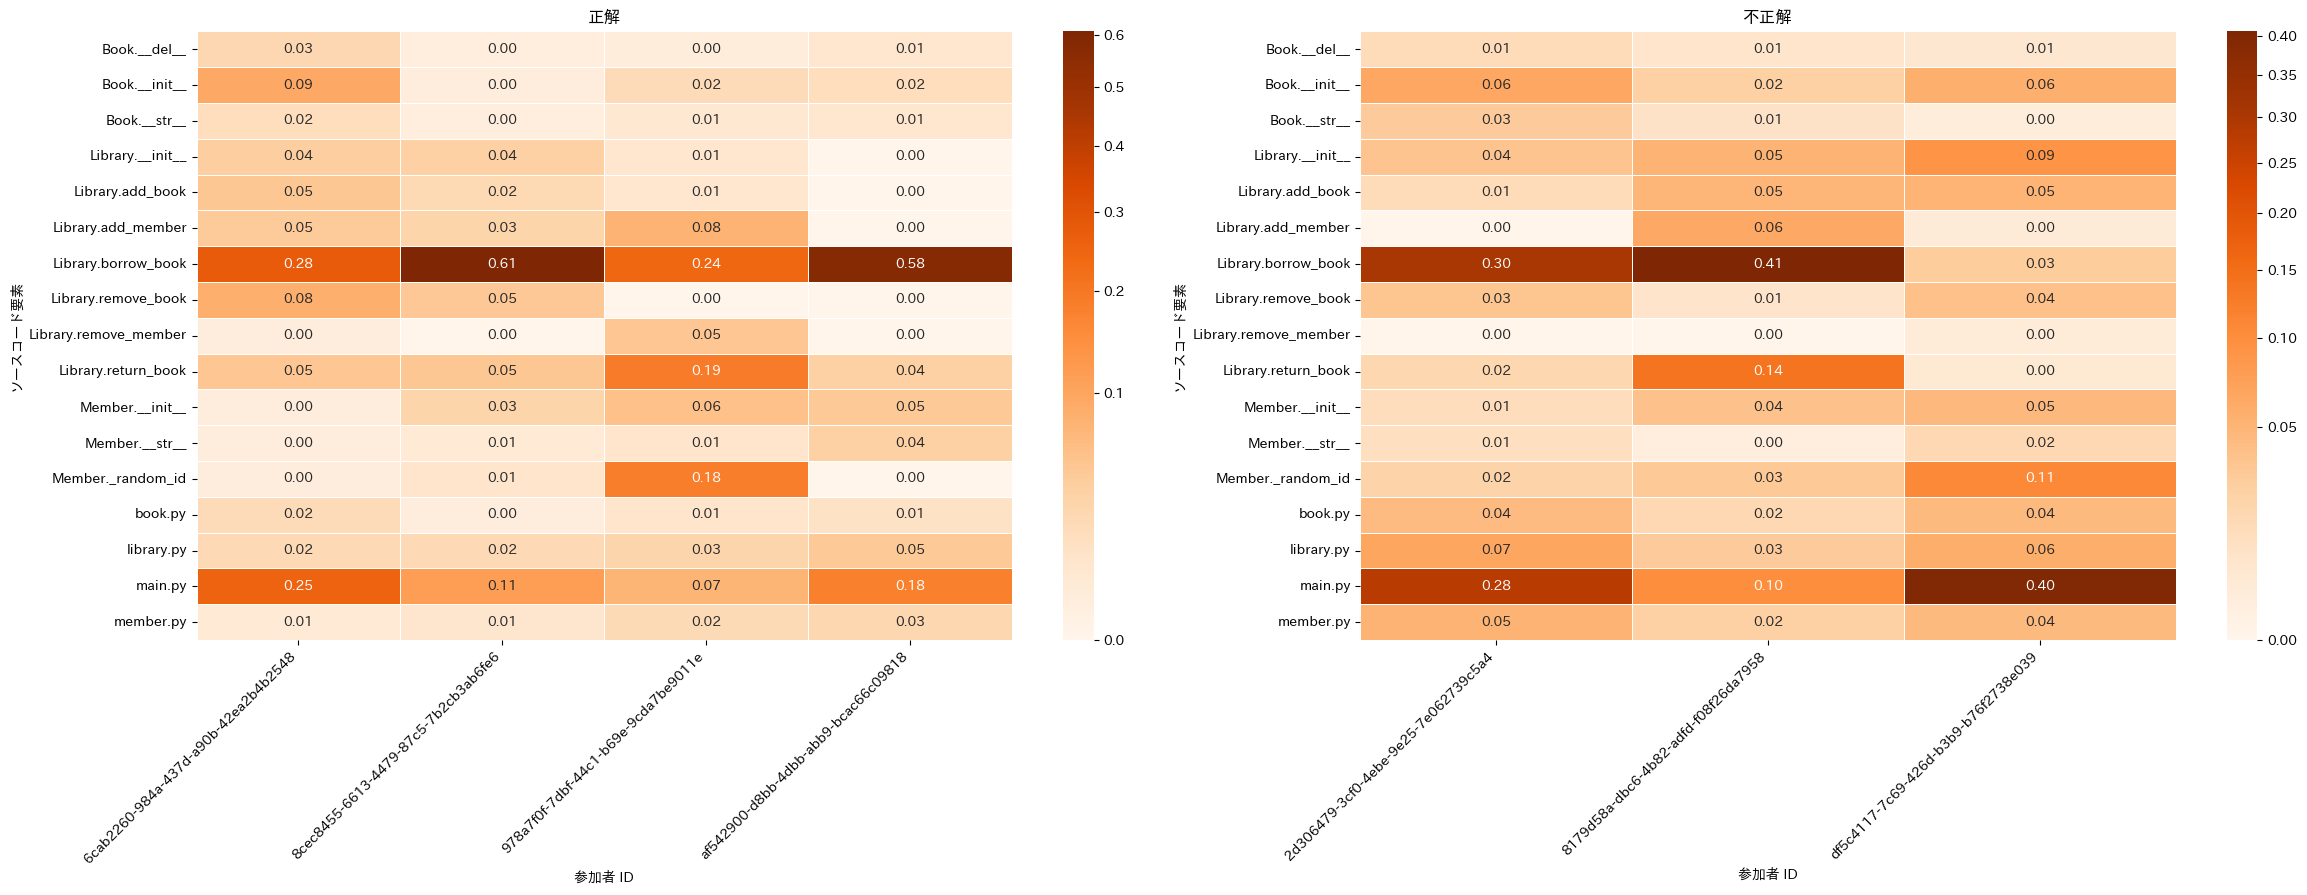

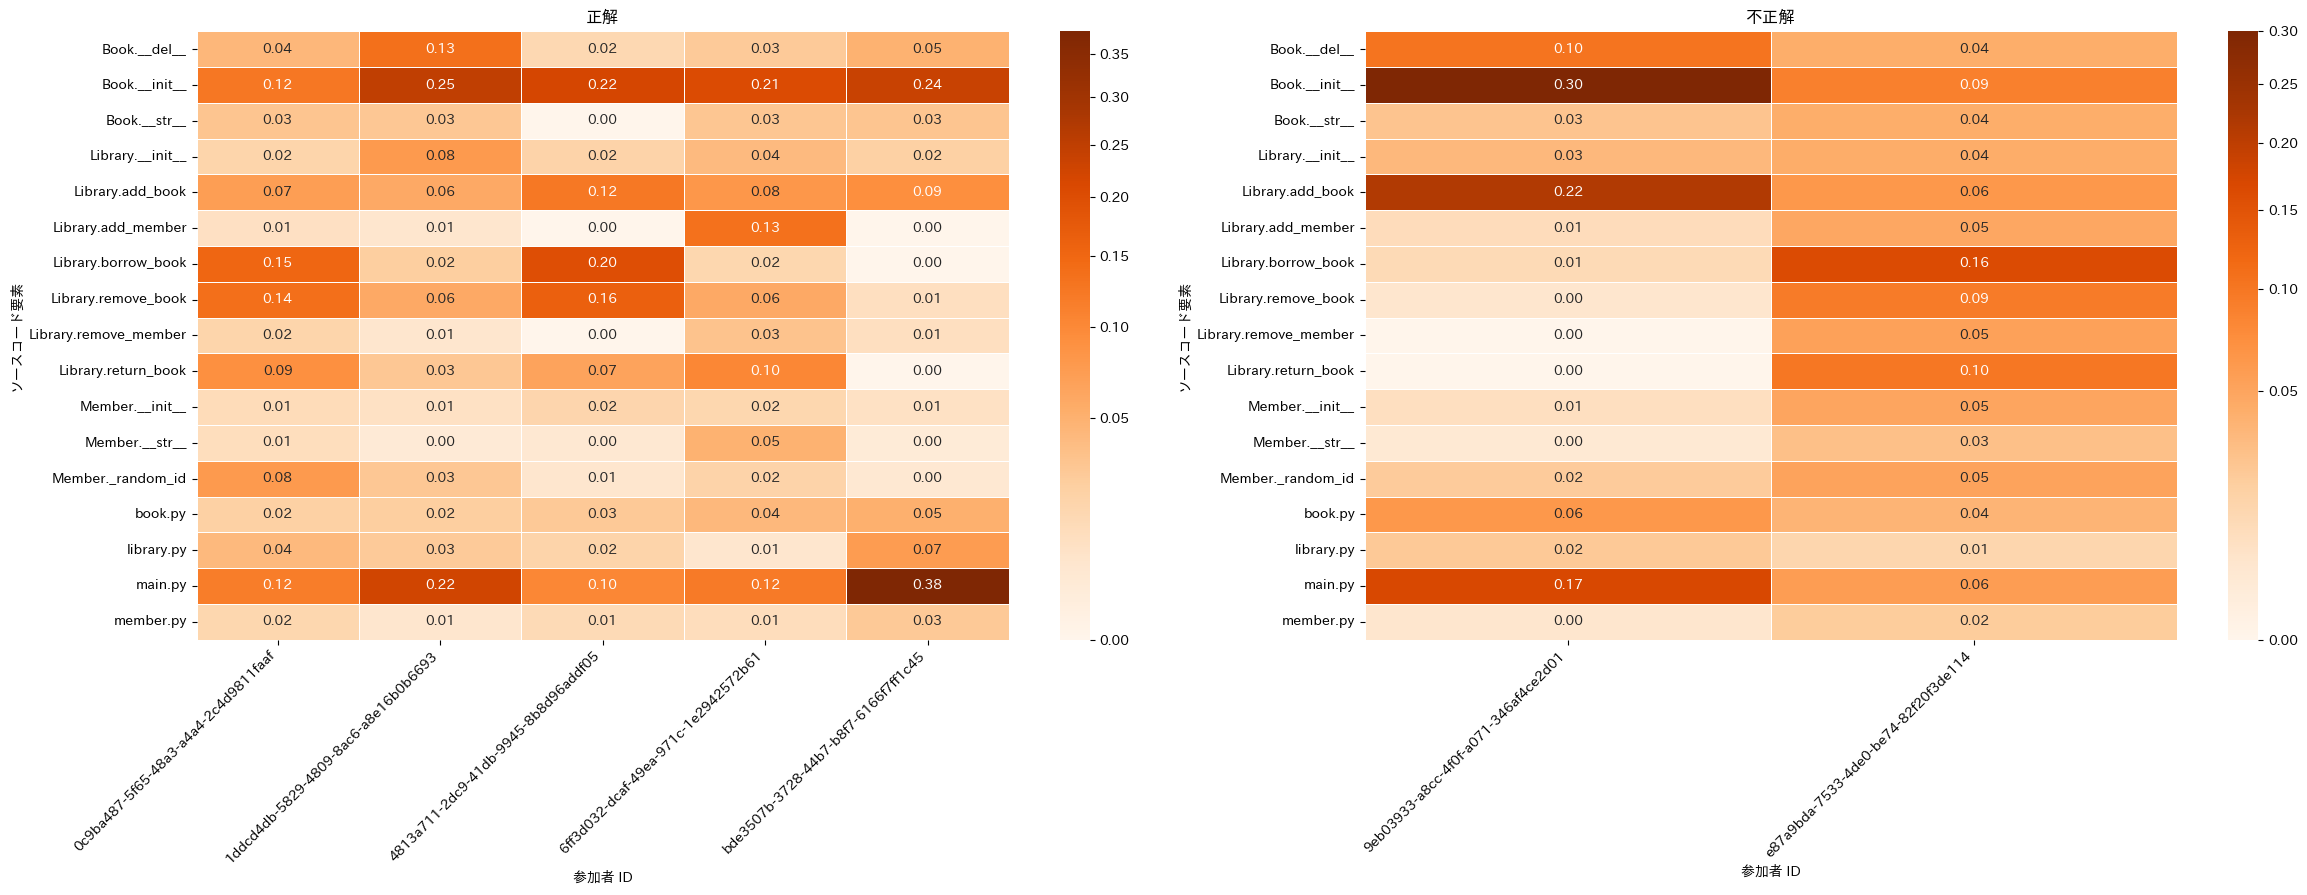

In [48]:
# exceed
fig_exceed, axes_exceed = plt.subplots(1, 2, figsize=(24, 10))
plot_heatmap_on_ax(axes_exceed[0], probs_exceed_correct_true, '正解', vmin, vmax)
plot_heatmap_on_ax(axes_exceed[1], probs_exceed_correct_false, '不正解', vmin, vmax)
fig_exceed.suptitle('', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Create a figure and two subplots for the 'duplicate' task
fig_duplicate, axes_duplicate = plt.subplots(1, 2, figsize=(24, 10))
plot_heatmap_on_ax(axes_duplicate[0], probs_duplicate_correct_true, '正解', vmin, vmax)
plot_heatmap_on_ax(axes_duplicate[1], probs_duplicate_correct_false, '不正解', vmin, vmax)
fig_duplicate.suptitle('', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### クラスを除いたヒートマップ

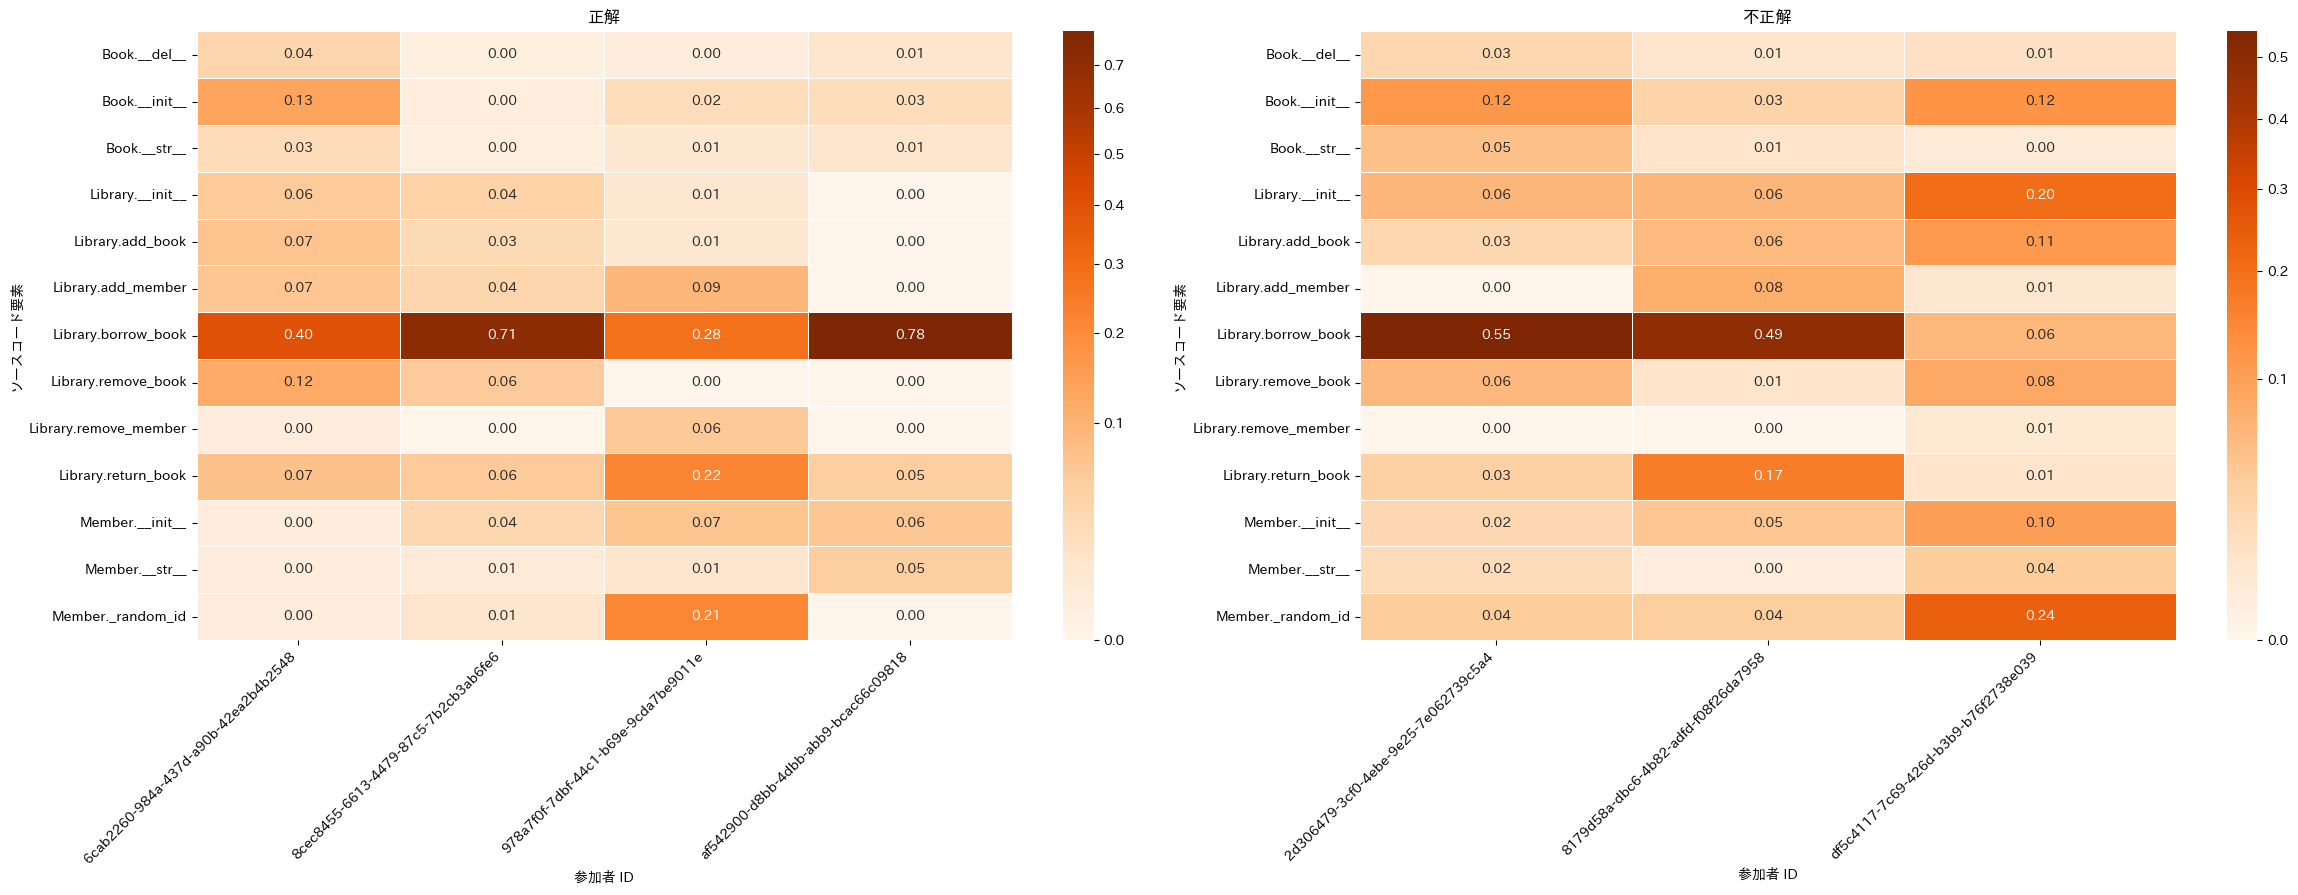

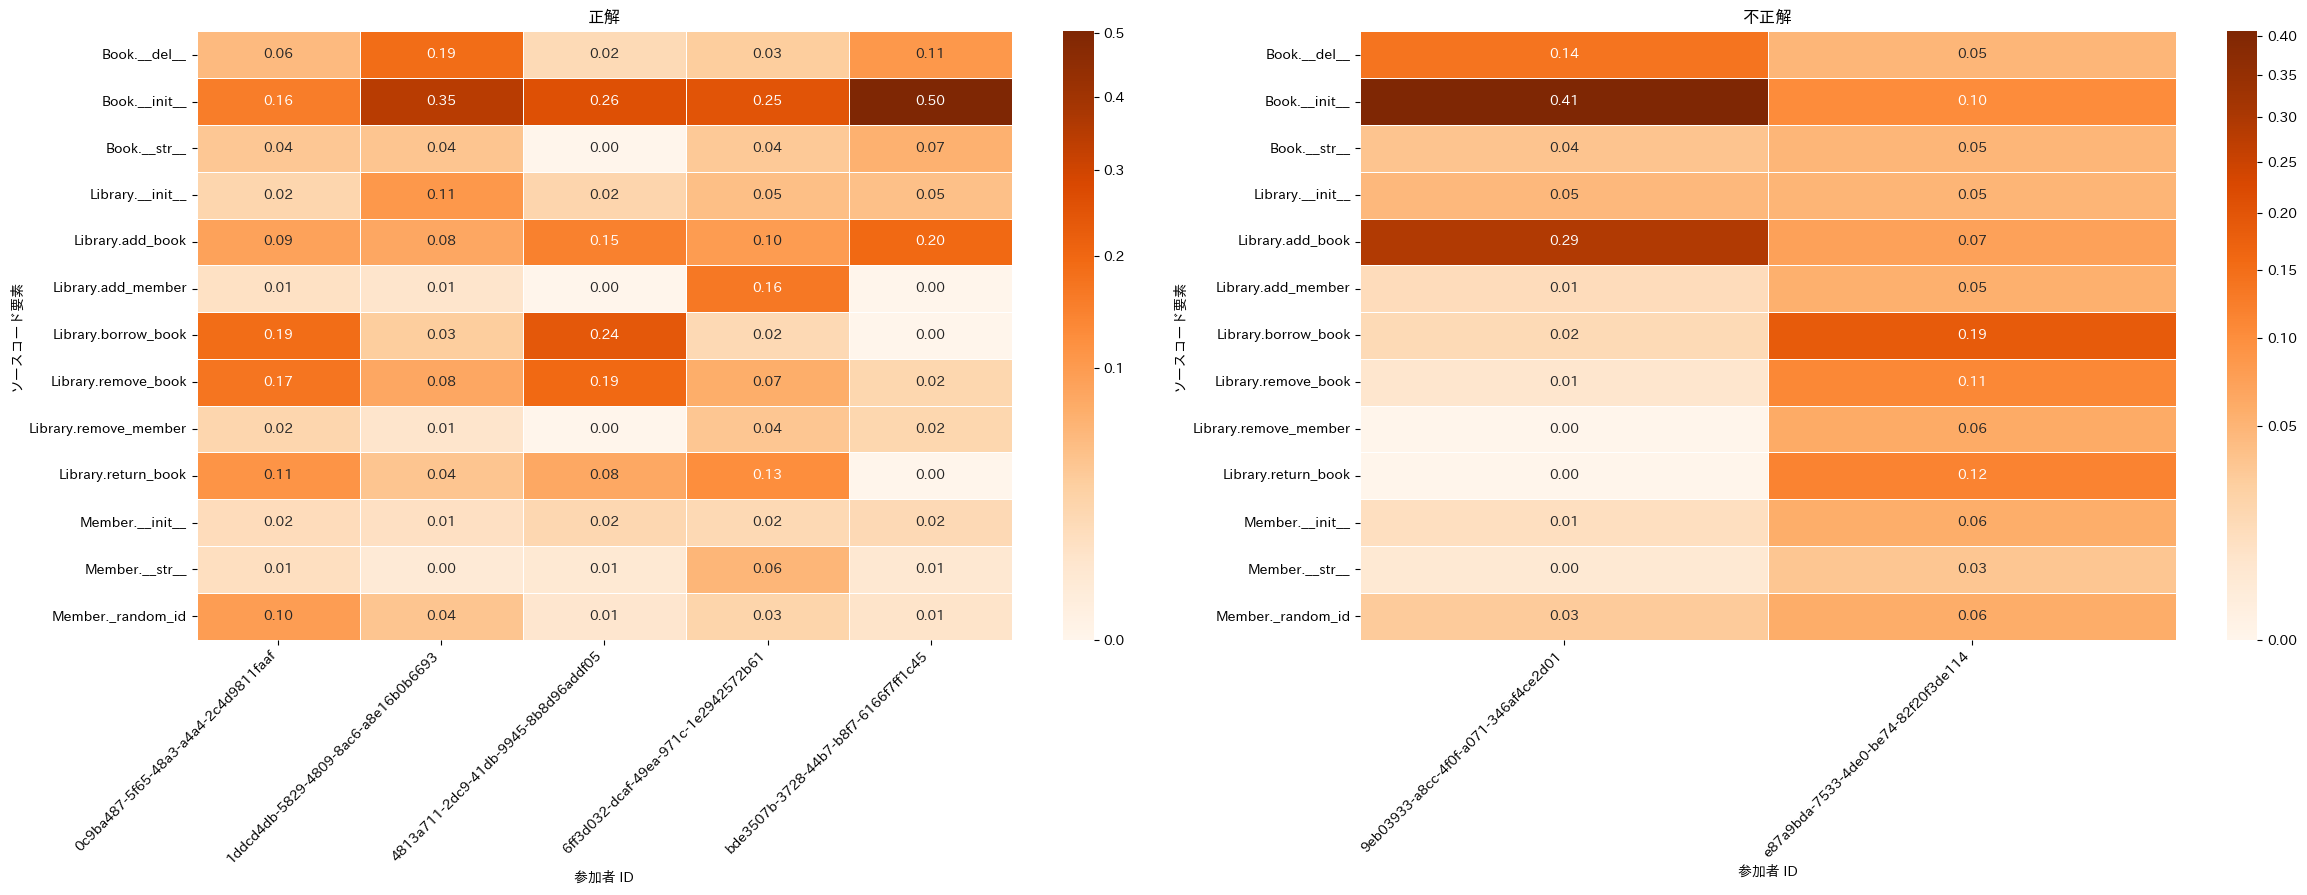

In [49]:
# Combine Exceed task heatmaps (Correct True and False, Filtered)
fig_exceed_filtered, axes_exceed_filtered = plt.subplots(1, 2, figsize=(24, 10))
plot_heatmap_on_ax(axes_exceed_filtered[0], probs_exceed_correct_true_filtered, '正解', vmin, vmax)
plot_heatmap_on_ax(axes_exceed_filtered[1], probs_exceed_correct_false_filtered, '不正解', vmin, vmax)
fig_exceed_filtered.suptitle('', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Combine Duplicate task heatmaps (Correct True and False, Filtered)
fig_duplicate_filtered, axes_duplicate_filtered = plt.subplots(1, 2, figsize=(24, 10))
plot_heatmap_on_ax(axes_duplicate_filtered[0], probs_duplicate_correct_true_filtered, '正解', vmin, vmax)
plot_heatmap_on_ax(axes_duplicate_filtered[1], probs_duplicate_correct_false_filtered, '不正解', vmin, vmax)
fig_duplicate_filtered.suptitle('', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## モデルとの比較

In [50]:
combined_exceed_true_df = pd.merge(mean_dist_exceed_correct_true.rename(columns={'mean_probability': 'mean_probability_exceed_true'}),
                                   stationary_distribution_exceed, left_index=True, right_index=True, how='outer').fillna(0)

combined_exceed_false_df = pd.merge(mean_dist_exceed_correct_false.rename(columns={'mean_probability': 'mean_probability_exceed_false'}),
                                    stationary_distribution_exceed, left_index=True, right_index=True, how='outer').fillna(0)

combined_duplicate_true_df = pd.merge(mean_dist_duplicate_correct_true.rename(columns={'mean_probability': 'mean_probability_duplicate_true'}),
                                      stationary_distribution_duplicate, left_index=True, right_index=True, how='outer').fillna(0)

combined_duplicate_false_df = pd.merge(mean_dist_duplicate_correct_false.rename(columns={'mean_probability': 'mean_probability_duplicate_false'}),
                                       stationary_distribution_duplicate, left_index=True, right_index=True, how='outer').fillna(0)

print("Combined DataFrames created: combined_exceed_true_df, combined_exceed_false_df, combined_duplicate_true_df, combined_duplicate_false_df")

Combined DataFrames created: combined_exceed_true_df, combined_exceed_false_df, combined_duplicate_true_df, combined_duplicate_false_df


In [51]:
from scipy.spatial.distance import jensenshannon
import numpy as np

# Extract the relevant columns and ensure they are probability distributions (sum to 1)
# exceed task, correct answers
r_exceed_true = combined_exceed_true_df['mean_probability_exceed_true']
z_exceed_true = combined_exceed_true_df['stationary_distribution_exceed']
r_exceed_true = r_exceed_true / r_exceed_true.sum()
z_exceed_true = z_exceed_true / z_exceed_true.sum()

# exceed task, incorrect answers
r_exceed_false = combined_exceed_false_df['mean_probability_exceed_false']
z_exceed_false = combined_exceed_false_df['stationary_distribution_exceed']
r_exceed_false = r_exceed_false / r_exceed_false.sum()
z_exceed_false = z_exceed_false / z_exceed_false.sum()

# duplicate task, correct answers
r_duplicate_true = combined_duplicate_true_df['mean_probability_duplicate_true']
z_duplicate_true = combined_duplicate_true_df['stationary_distribution_duplicate']
r_duplicate_true = r_duplicate_true / r_duplicate_true.sum()
z_duplicate_true = z_duplicate_true / z_duplicate_true.sum()

# duplicate task, incorrect answers
r_duplicate_false = combined_duplicate_false_df['mean_probability_duplicate_false']
z_duplicate_false = combined_duplicate_false_df['stationary_distribution_duplicate']
r_duplicate_false = r_duplicate_false / r_duplicate_false.sum()
z_duplicate_false = z_duplicate_false / z_duplicate_false.sum()

# Calculate Jensen-Shannon Divergence for each scenario
divergence_exceed_true = jensenshannon(r_exceed_true, z_exceed_true, base=2) ** 2
divergence_exceed_false = jensenshannon(r_exceed_false, z_exceed_false, base=2) ** 2
divergence_duplicate_true = jensenshannon(r_duplicate_true, z_duplicate_true, base=2) ** 2
divergence_duplicate_false = jensenshannon(r_duplicate_false, z_duplicate_false, base=2) ** 2

print(f"Jensen-Shannon Divergence for Exceed (Correct): {divergence_exceed_true}")
print(f"Jensen-Shannon Divergence for Exceed (Incorrect): {divergence_exceed_false}")
print(f"Jensen-Shannon Divergence for Duplicate (Correct): {divergence_duplicate_true}")
print(f"Jensen-Shannon Divergence for Duplicate (Incorrect): {divergence_duplicate_false}")

Jensen-Shannon Divergence for Exceed (Correct): 0.43284016035187345
Jensen-Shannon Divergence for Exceed (Incorrect): 0.3102352523684654
Jensen-Shannon Divergence for Duplicate (Correct): 0.27430383685833276
Jensen-Shannon Divergence for Duplicate (Incorrect): 0.24458684067592487


In [52]:
locations_to_exclude = ['book.py', 'library.py', 'main.py', 'member.py']

# Filter out the excluded locations from each combined DataFrame
filtered_combined_exceed_true_df = combined_exceed_true_df[~combined_exceed_true_df.index.isin(locations_to_exclude)].copy()
filtered_combined_exceed_false_df = combined_exceed_false_df[~combined_exceed_false_df.index.isin(locations_to_exclude)].copy()
filtered_combined_duplicate_true_df = combined_duplicate_true_df[~combined_duplicate_true_df.index.isin(locations_to_exclude)].copy()
filtered_combined_duplicate_false_df = combined_duplicate_false_df[~combined_duplicate_false_df.index.isin(locations_to_exclude)].copy()

# Normalize each column in the filtered dataframes to ensure they sum to 1
# This step is crucial for accurate Jensen-Shannon Divergence calculation after filtering
normalized_filtered_exceed_true_df = filtered_combined_exceed_true_df.apply(lambda x: x / x.sum(), axis=0)
normalized_filtered_exceed_false_df = filtered_combined_exceed_false_df.apply(lambda x: x / x.sum(), axis=0)
normalized_filtered_duplicate_true_df = filtered_combined_duplicate_true_df.apply(lambda x: x / x.sum(), axis=0)
normalized_filtered_duplicate_false_df = filtered_combined_duplicate_false_df.apply(lambda x: x / x.sum(), axis=0)

print("Filtered and normalized dataframes created: normalized_filtered_exceed_true_df, normalized_filtered_exceed_false_df, normalized_filtered_duplicate_true_df, normalized_filtered_duplicate_false_df")

Filtered and normalized dataframes created: normalized_filtered_exceed_true_df, normalized_filtered_exceed_false_df, normalized_filtered_duplicate_true_df, normalized_filtered_duplicate_false_df


In [53]:
from scipy.spatial.distance import jensenshannon
import numpy as np

# Extract the relevant columns for Jensen-Shannon Divergence from the normalized and filtered dataframes

# Exceed task, correct answers (filtered and normalized)
r_exceed_true_filtered = normalized_filtered_exceed_true_df['mean_probability_exceed_true']
z_exceed_true_filtered = normalized_filtered_exceed_true_df['stationary_distribution_exceed']

# Exceed task, incorrect answers (filtered and normalized)
r_exceed_false_filtered = normalized_filtered_exceed_false_df['mean_probability_exceed_false']
z_exceed_false_filtered = normalized_filtered_exceed_false_df['stationary_distribution_exceed']

# Duplicate task, correct answers (filtered and normalized)
r_duplicate_true_filtered = normalized_filtered_duplicate_true_df['mean_probability_duplicate_true']
z_duplicate_true_filtered = normalized_filtered_duplicate_true_df['stationary_distribution_duplicate']

# Duplicate task, incorrect answers (filtered and normalized)
r_duplicate_false_filtered = normalized_filtered_duplicate_false_df['mean_probability_duplicate_false']
z_duplicate_false_filtered = normalized_filtered_duplicate_false_df['stationary_distribution_duplicate']

# Calculate Jensen-Shannon Divergence for each filtered and normalized scenario
divergence_exceed_true_filtered = jensenshannon(r_exceed_true_filtered, z_exceed_true_filtered, base=2) ** 2
divergence_exceed_false_filtered = jensenshannon(r_exceed_false_filtered, z_exceed_false_filtered, base=2) ** 2
divergence_duplicate_true_filtered = jensenshannon(r_duplicate_true_filtered, z_duplicate_true_filtered, base=2) ** 2
divergence_duplicate_false_filtered = jensenshannon(r_duplicate_false_filtered, z_duplicate_false_filtered, base=2) ** 2

print(f"Jensen-Shannon Divergence for Exceed (Correct, Filtered & Normalized): {divergence_exceed_true_filtered}")
print(f"Jensen-Shannon Divergence for Exceed (Incorrect, Filtered & Normalized): {divergence_exceed_false_filtered}")
print(f"Jensen-Shannon Divergence for Duplicate (Correct, Filtered & Normalized): {divergence_duplicate_true_filtered}")
print(f"Jensen-Shannon Divergence for Duplicate (Incorrect, Filtered & Normalized): {divergence_duplicate_false_filtered}")

Jensen-Shannon Divergence for Exceed (Correct, Filtered & Normalized): 0.3853125546386063
Jensen-Shannon Divergence for Exceed (Incorrect, Filtered & Normalized): 0.24533295221636564
Jensen-Shannon Divergence for Duplicate (Correct, Filtered & Normalized): 0.15638730582906948
Jensen-Shannon Divergence for Duplicate (Incorrect, Filtered & Normalized): 0.1608839392138587
